# Evaluation Script Big Model

## Set up and imports

In [1]:
import sys

COLAB = "google.colab" in sys.modules

# Environment Setup
if COLAB:
    print("Running in Google Colab. Setting up environment...")
    BASE_DIR = './'  # In Colab, everything stays inside /content/

    import gdown
    requirements_ID = '1XHtGbTN-NEHnvAyM7ufYi4mw0K2lN9NN'
    gdown.download(id=requirements_ID, output='requirements.txt', quiet=False)
    %pip install -r "requirements.txt"
else:
    print("Running locally. Assuming files are already present.")
    BASE_DIR = '../' # Locally, everything is one level up from /src

    requirements_path = f"{BASE_DIR}requirements.txt"
    %pip install -r "{requirements_path}"

Running in Google Colab. Setting up environment...


Downloading...
From: https://drive.google.com/uc?id=1XHtGbTN-NEHnvAyM7ufYi4mw0K2lN9NN
To: /content/requirements.txt
100%|██████████| 164/164 [00:00<00:00, 413kB/s]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.1/179.1 kB 7.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 44.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 622.7 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 28.4 MB/s e

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
import tf_keras as keras
from tf_keras.models import load_model
import akida
import quantizeml
from quantizeml.models import quantize, QuantizationParams
from cnn2snn import load_quantized_model, set_akida_version, AkidaVersion
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Force legacy Keras BEFORE importing TensorFlow
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Notice the double underscores!
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras module: {keras.__name__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.19.1
Keras module: tf_keras
Keras version: 2.19.0


## Dataset download and load
We directly download and load the preprocessed, hand-oriented filtered (small) of our dataset, bypassing the raw data processing steps

In [6]:
# Dataset download
dataset_dir = os.path.join(BASE_DIR, 'data/processed_data/filtered')
dataset_path = os.path.join(dataset_dir, 'X_watch_20Hz_scaled_big.npy')
labels_path = os.path.join(dataset_dir, 'y_watch_labels_big.npy')

if not os.path.exists(dataset_path) or not os.path.exists(labels_path):
    dataset_ID = '1J0j7FzpsfXdbFFaTqgIH1XNjQT31SQDC'
    labels_ID = '1QK7vxsYoPedcbsWKziA4NOp9x4SMVqH4'

    print(f"Dataset or labels not found in {dataset_dir}. Downloading...")
    os.makedirs(dataset_dir, exist_ok=True)
        
    gdown.download(id=dataset_ID, output=dataset_path, quiet=False)
    gdown.download(id=labels_ID, output=labels_path, quiet=False)
    print("Download complete!")
else:
    print(f"Dataset and labels already exist in {dataset_dir}. Skipping download.")

Dataset or labels not found in ./data/processed_data/filtered. Downloading...


Downloading...
From (original): https://drive.google.com/uc?id=1J0j7FzpsfXdbFFaTqgIH1XNjQT31SQDC
From (redirected): https://drive.google.com/uc?id=1J0j7FzpsfXdbFFaTqgIH1XNjQT31SQDC&confirm=t&uuid=75a35eda-99cf-46e1-8817-fb153a0fd711
To: /content/data/processed_data/filtered/X_watch_20Hz_scaled_big.npy
100%|██████████| 161M/161M [00:03<00:00, 52.1MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1QK7vxsYoPedcbsWKziA4NOp9x4SMVqH4
To: /content/data/processed_data/filtered/y_watch_labels_big.npy
100%|██████████| 1.34M/1.34M [00:00<00:00, 84.8MB/s]

Download complete!


In [7]:
# Dataset load
try:
    X_data = np.load(dataset_path)
    y_labels = np.load(labels_path).astype(np.int32)

    print(f"Dataset loaded successfully from: {dataset_path}")
    print(f"Labels loaded successfully from: {labels_path}")

    print(f"\nX_data shape: {X_data.shape}")
    print(f"y_labels shape: {y_labels.shape}, dtype: {y_labels.dtype}")

except FileNotFoundError:
    print(f"Error: One or both files were not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully from: ./data/processed_data/filtered/X_watch_20Hz_scaled_big.npy
Labels loaded successfully from: ./data/processed_data/filtered/y_watch_labels_big.npy

X_data shape: (167247, 40, 6)
y_labels shape: (167247,), dtype: int32


## Dataset split and preprocess

In [8]:
def split_and_save_dataset(X, y, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train_size, random_state=random_state, stratify=y
    )

    relative_val_size = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=relative_val_size, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [9]:
X_train, X_val, X_test, y_train, y_val, y_test = split_and_save_dataset(X_data, y_labels, train_size=0.7, val_size=0.15, test_size=0.15)

# We remap the labels to a continuous interval [0, N-1]
unique_labels = np.unique(y_train)
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}

def apply_mapping(labels, mapping):
    return np.array([mapping[label] for label in labels], dtype=np.int32)

y_train = apply_mapping(y_train, label_mapping)
y_val = apply_mapping(y_val, label_mapping)
y_test = apply_mapping(y_test, label_mapping)

num_classes = len(unique_labels)

print(f"Number of unique classes detected: {num_classes}")
print(f"Applied mapping: {label_mapping}")
print(f"X_train dimensions: {X_train.shape}, y_train: {y_train.shape}")

Number of unique classes detected: 18
Applied mapping: {np.int32(0): 0, np.int32(1): 1, np.int32(2): 2, np.int32(3): 3, np.int32(4): 4, np.int32(5): 5, np.int32(6): 6, np.int32(7): 7, np.int32(8): 8, np.int32(9): 9, np.int32(10): 10, np.int32(11): 11, np.int32(12): 12, np.int32(13): 13, np.int32(14): 14, np.int32(15): 15, np.int32(16): 16, np.int32(17): 17}
X_train dimensions: (117072, 40, 6), y_train: (117072,)


In [10]:
activity_id_to_name = {
    0: 'Walking',
    1: 'Jogging',
    2: 'Stairs',
    3: 'Sitting',
    4: 'Standing',
    5: 'Typing',
    6: 'Teeth',
    7: 'Soup',
    8: 'Chips',
    9: 'Pasta',
    10: 'Drinking',
    11: 'Sandwitch',
    12: 'Kicking',
    13: 'Catch',
    14: 'Dribbling',
    15: 'Writing',
    16: 'Clapping',
    17: 'Folding'
}

# Create an ordered list of original labels based on the `label_mapping` values
ordered_original_labels = sorted(label_mapping, key=label_mapping.get)

# Get the activity names in the correct order for the confusion matrix axes
activity_names_for_cm = [activity_id_to_name[label] for label in ordered_original_labels]

In [11]:
# Input reshape
X_train_reshaped = X_train.reshape(-1, 40, 6, 1)
X_val_reshaped = X_val.reshape(-1, 40, 6, 1)
X_test_reshaped = X_test.reshape(-1, 40, 6, 1)

pad_config = ((0,0), (0,1), (1,2), (0,0))
X_train_padded = np.pad(X_train_reshaped, pad_width=pad_config, mode='constant', constant_values=0)
X_val_padded = np.pad(X_val_reshaped, pad_width=pad_config, mode='constant', constant_values=0)
X_test_padded = np.pad(X_test_reshaped, pad_width=pad_config, mode='constant', constant_values=0)

x_min = np.min(X_train_padded)
x_max = np.max(X_train_padded)

# Range [0.0, 1.0] in float32
X_train = ((X_train_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)
X_val = ((X_val_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)
X_test = ((X_test_padded - x_min) / (x_max - x_min + 1e-8)).astype(np.float32)

## Evaluation Big Model (CNN)

In [12]:
# Model download
models_dir = os.path.join(BASE_DIR, 'models')
model_path = os.path.join(models_dir, 'bestModel.h5')

if not os.path.exists(model_path):
    model_ID = '1CTBNHZydcGF_7InxYIJA8FgTlbq5gCnZ'

    print(f"Model not found in {models_dir}. Downloading...")
    os.makedirs(models_dir, exist_ok=True)
        
    gdown.download(id=model_ID, output=model_path, quiet=False)
    print("Download complete!")
else:
    print(f"Model already exist in {models_dir}. Skipping download.")

Model not found in ./models. Downloading...


Downloading...
From: https://drive.google.com/uc?id=1CTBNHZydcGF_7InxYIJA8FgTlbq5gCnZ
To: /content/models/bestModel.h5
100%|██████████| 3.70M/3.70M [00:00<00:00, 103MB/s]

Download complete!


In [14]:
cnn_model = load_model(model_path)
print("Big model (CNN) loaded successfully from the .h5 file!\n")

cnn_model.summary()

# Evaluation on Test Set
print("\n--- Evaluation on Test Set ---")
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy of Big model CNN: {test_accuracy * 100:.2f}%")

Big model (CNN) loaded successfully from the .h5 file!

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 21, 5, 32)         320       
                                                                 
 re_lu_19 (ReLU)             (None, 21, 5, 32)         0         
                                                                 
 conv2d_13 (Conv2D)          (None, 11, 3, 128)        36992     
                                                                 
 re_lu_20 (ReLU)             (None, 11, 3, 128)        0         
                                                                 
 conv2d_14 (Conv2D)          (None, 6, 2, 192)         221376    
                                                                 
 re_lu_21 (ReLU)             (None, 6, 2, 192)         0         
                                                                

## Evaluation Big Model Quantized
Because the quantized model was saved as a weights-only file to prevent deserialization issues with custom Keras layers, we must first recreate the model architecture. 
We achieve this on the fly by applying the `quantize()` function to the base float model, using the exact same calibration parameters from the training phase. Once the architecture is reconstructed, we load the saved weights into the model using `.load_weights()` prior to evaluation.

In [15]:
# Quantized Model download
quantized_model_path = os.path.join(models_dir, 'bestModel_quantized.h5')

if not os.path.exists(quantized_model_path):
    quantized_model_ID = '1BwNzPmtjpmzebVltBjGYHON_Iv0NXAFh'

    print(f"Quantized model not found in {models_dir}. Downloading...")
    os.makedirs(models_dir, exist_ok=True)
        
    gdown.download(id=quantized_model_ID, output=quantized_model_path, quiet=False)
    print("Download complete!")
else:
    print(f"Quantized model already exist in {models_dir}. Skipping download.")

Quantized model not found in ./models. Downloading...


Downloading...
From: https://drive.google.com/uc?id=1BwNzPmtjpmzebVltBjGYHON_Iv0NXAFh
To: /content/models/bestModel_quantized.h5
100%|██████████| 1.27M/1.27M [00:00<00:00, 106MB/s]

Download complete!


In [16]:
qparams = QuantizationParams(
    input_weight_bits=8,
    weight_bits=4,
    activation_bits=4,
)

num_calibration_samples = 2048
indices = np.random.choice(len(X_train), num_calibration_samples, replace=False)
calibration_data = X_train[indices]

with set_akida_version(AkidaVersion.v1):
    quantized_model = quantize(
        cnn_model,
        qparams=qparams,
        samples=calibration_data
    )

quantized_model.load_weights(quantized_model_path)
print("Quantized model weights loaded successfully from the .h5 file!")

quantized_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

1024/1024 [==============================] - 5s 4ms/step
Quantized model weights loaded successfully from the .h5 file!


In [17]:
quantized_model.summary()

# Evaluation on Test Set
print("\n--- Evaluation on Test Set ---")
test_loss, test_accuracy = quantized_model.evaluate(X_test, y_test)
print(f"Test Accuracy of Quantized model: {test_accuracy * 100:.2f}%")

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 41, 9, 1)]        0         
                                                                 
 input_quantizer (InputQuan  (None, 41, 9, 1)          2         
 tizer)                                                          
                                                                 
 conv2d_12 (QuantizedConv2D  (None, 21, 5, 32)         320       
 )                                                               
                                                                 
 re_lu_19 (QuantizedReLU)    (None, 21, 5, 32)         64        
                                                                 
 conv2d_13 (QuantizedConv2D  (None, 11, 3, 128)        36992     
 )                                                               
                                                      

## Evaluation Akida Model

In [18]:
# Akida Model download
akida_model_path = os.path.join(models_dir, 'bestModel_quantized_akida.fb')

if not os.path.exists(akida_model_path):
    akida_model_ID = '1ckIfQ189VylSFs9qmzwORiC7EwSO5wTk'

    print(f"Akida model not found in {models_dir}. Downloading...")
    os.makedirs(models_dir, exist_ok=True)
        
    gdown.download(id=akida_model_ID, output=akida_model_path, quiet=False)
    print("Download complete!")
else:
    print(f"Akida model already exist in {models_dir}. Skipping download.")

Akida model not found in ./models. Downloading...


Downloading...
From: https://drive.google.com/uc?id=1ckIfQ189VylSFs9qmzwORiC7EwSO5wTk
To: /content/models/bestModel_quantized_akida.fb
100%|██████████| 364k/364k [00:00<00:00, 65.6MB/s]

Download complete!


In [19]:
akida_model = akida.Model(akida_model_path)
print("Akida SNN model loaded successfully from the .fb file!\n")

akida_model.summary()

# Evaluation on Test Set
print("\n--- Evaluation on Test Set (Akida Execution) ---")
test_accuracy = akida_model.evaluate(X_test, y_test)
print(f"Test Accuracy of Akida SNN model: {test_accuracy * 100:.2f}%")

Akida SNN model loaded successfully from the .fb file!

                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[41, 9, 1]   [1, 1, 18]    1          7     
______________________________________________

_______________________________________________________________
Layer (type)                   Output shape  Kernel shape    

=========== SW/input_quantizer_9-dense_7 (Software) ===========

input_quantizer_9 (Quantizer)  [41, 9, 1]    N/A             
_______________________________________________________________
conv2d_12 (InputConv.)         [21, 5, 32]   (3, 3, 1, 32)   
_______________________________________________________________
conv2d_13 (Conv.)              [11, 3, 128]  (3, 3, 32, 128) 
_______________________________________________________________
conv2d_14 (Conv.)              [6, 2, 192]   (3, 3, 128, 192)
_______________________________________________________________
conv2d_15 (Conv.

## Mapping to Hardware

In [20]:
# Load Model First
akida_model = akida.Model(akida_model_path)
print("SNN model loaded into memory.")

# Hardware Detection
available_devices = akida.devices()

if len(available_devices) == 0:
    print("\nNo physical Akida hardware detected! The code will use the software simulator.")
elif len(available_devices) > 0:
    device = available_devices[0]
    print(f"\nPhysical hardware successfully detected: {device}")

    akida_model.map(device)
    print(f"Model mapped and executed on hardware.")

akida_model.summary()

# Inference
# If .map() was called, this runs on the AKD1000
# If .map() was skipped, this automatically runs on the CPU Simulator
print("\n--- Starting inference ---")
test_samples = X_test
preds = akida_model.predict(test_samples)

akida_preds = np.argmax(preds, axis=-1).flatten()
akida_accuracy = np.mean(akida_preds == y_test)
print(f"Akida Accuracy: {akida_accuracy * 100:.2f}%")

print("\n--- Execution statistics ---")
print(akida_model.statistics)

SNN model loaded into memory.

No physical Akida hardware detected! The code will use the software simulator.
                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[41, 9, 1]   [1, 1, 18]    1          7     
______________________________________________

_______________________________________________________________
Layer (type)                   Output shape  Kernel shape    

=========== SW/input_quantizer_9-dense_7 (Software) ===========

input_quantizer_9 (Quantizer)  [41, 9, 1]    N/A             
_______________________________________________________________
conv2d_12 (InputConv.)         [21, 5, 32]   (3, 3, 1, 32)   
_______________________________________________________________
conv2d_13 (Conv.)              [11, 3, 128]  (3, 3, 32, 128) 
_______________________________________________________________
conv2d_14 (Conv.)              [6, 2, 192]   (3, 3, 128, 192)
__________________________

## Confusion Matrix

Confusion Matrix:
[[1170    1   91    1    1    0    5    1    1    5    0    3   57    9
     8    0    6   28]
 [   4 1297   13    1    0    0    0    0    0    1    0    1    5   13
     6    0    3    8]
 [ 106   17  932    5    4    0    4    1    3    1    1    4  177   32
     6    1    4   67]
 [   1    0    1  946   49  112    8   27   21   45  102   25    2    5
     2   54    4   31]
 [   5    0    5   70 1123   16   11   22   23   29   19   31   36    7
    14   23    0   21]
 [   0    0    0   75   20 1032    0    6    7   20    3   11    0    0
     0  142    0    4]
 [   1    0    6    5   18    0 1206    3   12   17   13   25    6    0
     3    2   51   18]
 [   2    0    1   21   26   17    6  810   47  234   59   64    2    4
     1   64    1   22]
 [   0    0    4   63   46  100   19   60  584  144  134  161    2    4
     3   38    1   25]
 [   2    0    0   35    8   69    7  190   50  871   30   59    0    1
     1   45    3   35]
 [   0    0    0   42   42   38 

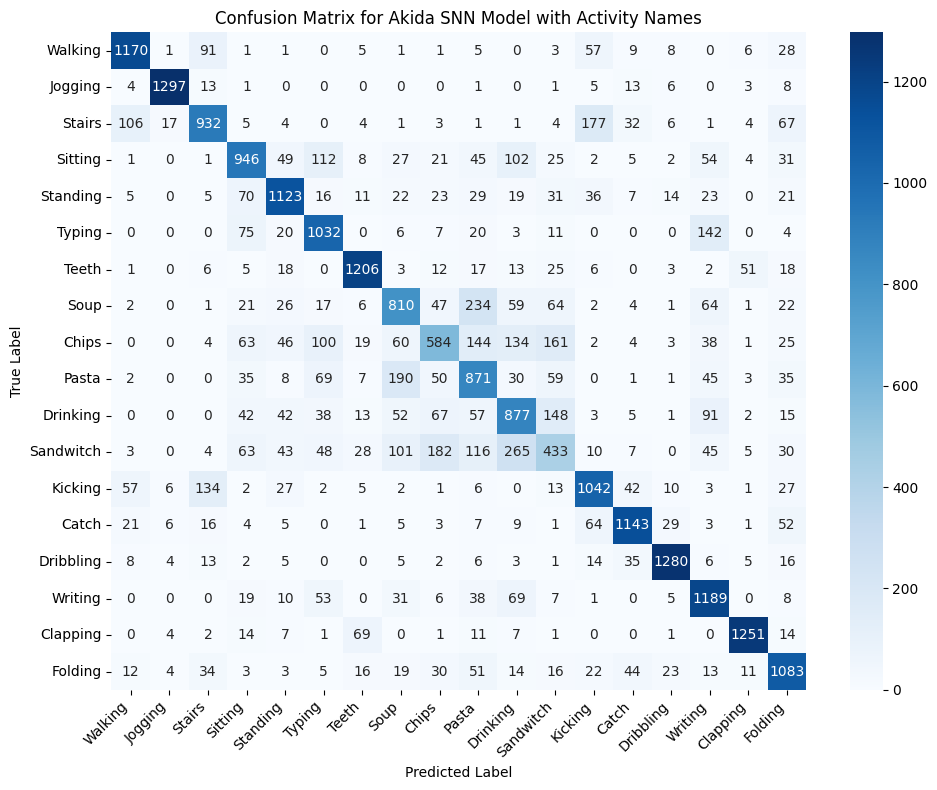

In [21]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, akida_preds)

# Print the confusion matrix (optional)
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix using descriptive names
plt.figure(figsize=(10, 8)) # Adjust figure size for better readability of longer labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names_for_cm, yticklabels=activity_names_for_cm)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Akida SNN Model with Activity Names')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()